Seleção de colunas e PCA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
from sklearn.model_selection import TimeSeriesSplit
import time
import psutil
import os

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("./raw/dataset_merged_binary.csv", parse_dates=["date"])

cols = ["date", "credit_spread", "credit_spread_diff", "industrial_production", "industrial_production_mom", "industrial_production_yoy", "price_index", "inflation_mom",
    "inflation_yoy", "real_interest", "real_interest_diff", "volatility_index", "volatility_index_mom", "yield_curve_slope", "yield_curve_slope_diff", "target_12m"]

df = df[cols].dropna().reset_index(drop=True)

features = ["credit_spread", "credit_spread_diff", "industrial_production", "industrial_production_mom", "industrial_production_yoy", "price_index", "inflation_mom",
    "inflation_yoy", "real_interest", "real_interest_diff", "volatility_index", "volatility_index_mom", "yield_curve_slope", "yield_curve_slope_diff"]

Matriz de Correlação

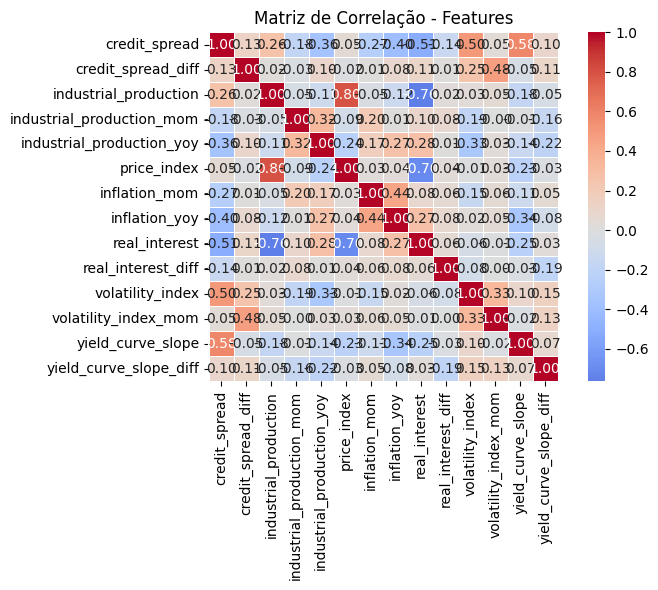

Matriz de Correlação:
                           credit_spread  credit_spread_diff  industrial_production  industrial_production_mom  industrial_production_yoy  price_index  inflation_mom  inflation_yoy  real_interest  real_interest_diff  volatility_index  volatility_index_mom  yield_curve_slope  yield_curve_slope_diff
credit_spread                   1.000000            0.130974               0.261203                  -0.182236                  -0.358902     0.050529      -0.265613      -0.404380      -0.514573           -0.138257          0.497201              0.045053           0.578270                0.102934
credit_spread_diff              0.130974            1.000000               0.016354                  -0.026486                   0.100941    -0.017295       0.008910       0.078325       0.106229            0.009533          0.254145              0.475916          -0.049492                0.108439
industrial_production           0.261203            0.016354               1.0000

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlação - Features")
plt.tight_layout()
plt.show()

print("Matriz de Correlação:")
print(corr.to_string())

Divisão entre treino e teste

In [3]:
from sklearn.model_selection import train_test_split

# Ordena cronologicamente
df = df.sort_values("date").reset_index(drop=True)

X = df[features]
y = df["target_12m"]

# ==========================
# Divisão treino / teste
# ==========================

X_train_no_pca, X_test_no_pca, y_train_no_pca, y_test_no_pca = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    shuffle=False
)

# ==========================
# StandardScaler
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_no_pca)
X_test_scaled = scaler.transform(X_test_no_pca)

# ==========================
# PCA
# ==========================

pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ==========================
# Variância explicada
# ==========================

variancia_explicada = pca.explained_variance_ratio_
variancia_total = variancia_explicada.sum()

print(f"Variância explicada pela PC1: {variancia_explicada[0]:.2%}")
print(f"Variância explicada pela PC2: {variancia_explicada[1]:.2%}")
print(f"Variância explicada pela PC3: {variancia_explicada[2]:.2%}")
print(f"Variância total explicada: {variancia_total:.2%}")

# ==========================
# DataFrames PCA (mantidos)
# ==========================

X_train_pca = pd.DataFrame(
    X_train_pca,
    columns=["pca_1", "pca_2", "pca_3"],
    index=X_train_no_pca.index
)

X_test_pca = pd.DataFrame(
    X_test_pca,
    columns=["pca_1", "pca_2", "pca_3"],
    index=X_test_no_pca.index
)

# Targets para os modelos com PCA
y_train_pca = y_train_no_pca.copy()
y_test_pca = y_test_no_pca.copy()

Variância explicada pela PC1: 29.02%
Variância explicada pela PC2: 14.79%
Variância explicada pela PC3: 10.83%
Variância total explicada: 54.64%


Função base de treino, teste e plot dos modelos

In [4]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

import matplotlib.pyplot as plt
import pandas as pd

LABELS = ["Normal", "Crise"]
ALL_CLASSES = [0, 1]

resultados = []

def avaliar_modelo(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    nome_modelo="Modelo",
    tempo_treino=None,
    tempo_predicao=None,
    memoria_mb=None
):

    print(f"\n===== {nome_modelo} =====")

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\n--- TREINO ---")
    print(
        classification_report(
            y_train,
            y_pred_train,
            labels=ALL_CLASSES,
            target_names=LABELS,
            zero_division=0
        )
    )

    print("\n--- TESTE ---")
    print(
        classification_report(
            y_test,
            y_pred_test,
            labels=ALL_CLASSES,
            target_names=LABELS,
            zero_division=0
        )
    )

    # ===== INFORMAÇÕES COMPUTACIONAIS =====

    if tempo_treino is not None:
        print(f"\nTempo de treino: {tempo_treino:.4f} s")

    if tempo_predicao is not None:
        print(f"Tempo de predição: {tempo_predicao * 1000:.4f} ms")

    if memoria_mb is not None:
        print(f"Memória utilizada: {memoria_mb:.2f} MB")

    # ===== ACUMULA RESULTADOS =====
    resultados.append({
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(
            y_test,
            y_pred_test,
            average="macro",
            labels=ALL_CLASSES,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_test,
            average="macro",
            labels=ALL_CLASSES,
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_test,
            y_pred_test,
            average="macro",
            labels=ALL_CLASSES,
            zero_division=0
        ),
        "tempo_treino_s": tempo_treino
    })

    # ===== MATRIZES DE CONFUSÃO =====

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    cm_train = confusion_matrix(
        y_train,
        y_pred_train,
        labels=ALL_CLASSES
    )

    ConfusionMatrixDisplay(
        cm_train,
        display_labels=LABELS
    ).plot(
        ax=axes[0],
        xticks_rotation=45,
        cmap="Reds"
    )

    axes[0].set_title(
        f"{nome_modelo} - Matriz de Confusão (Treino)"
    )

    cm_test = confusion_matrix(
        y_test,
        y_pred_test,
        labels=ALL_CLASSES
    )

    ConfusionMatrixDisplay(
        cm_test,
        display_labels=LABELS
    ).plot(
        ax=axes[1],
        xticks_rotation=45,
        cmap="Reds"
    )

    axes[1].set_title(
        f"{nome_modelo} - Matriz de Confusão (Teste)"
    )

    plt.tight_layout()
    plt.show()

Árvore de Decisão


===== Decision Tree (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.93      0.93      0.93       147
       Crise       0.94      0.93      0.93       157

    accuracy                           0.93       304
   macro avg       0.93      0.93      0.93       304
weighted avg       0.93      0.93      0.93       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.76      0.59      0.67        91
       Crise       0.38      0.57      0.46        40

    accuracy                           0.59       131
   macro avg       0.57      0.58      0.56       131
weighted avg       0.65      0.59      0.60       131


Tempo de treino: 0.0157 s
Tempo de predição: 0.0000 ms
Memória utilizada: 202.23 MB


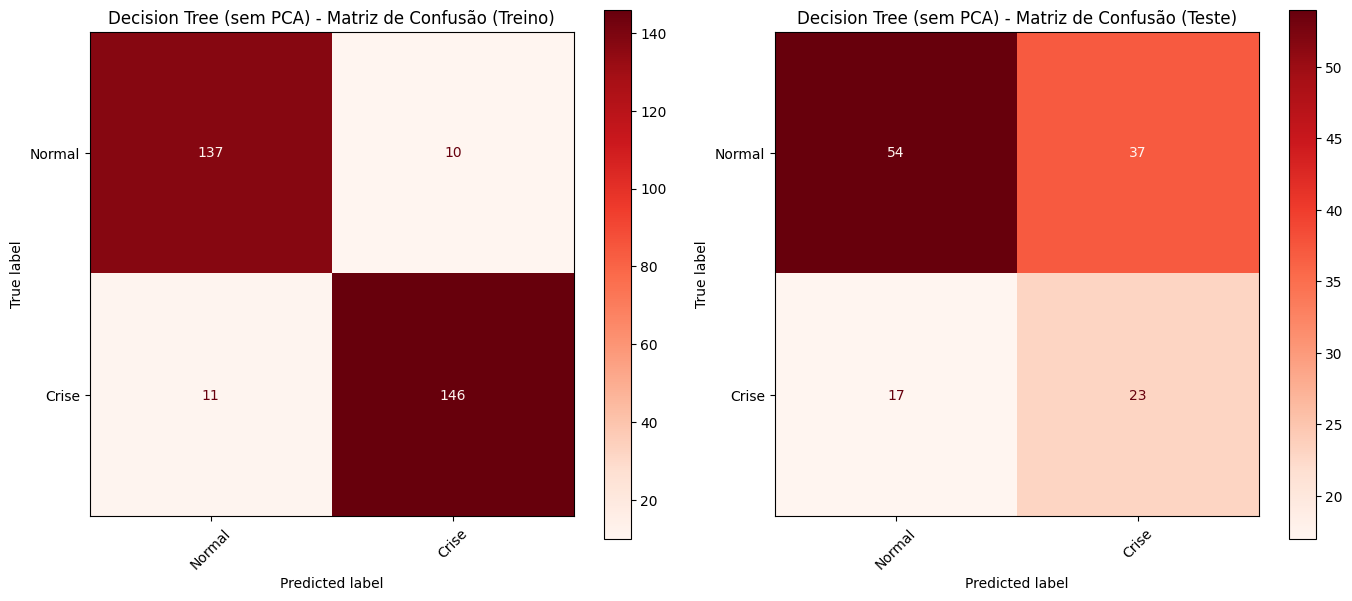

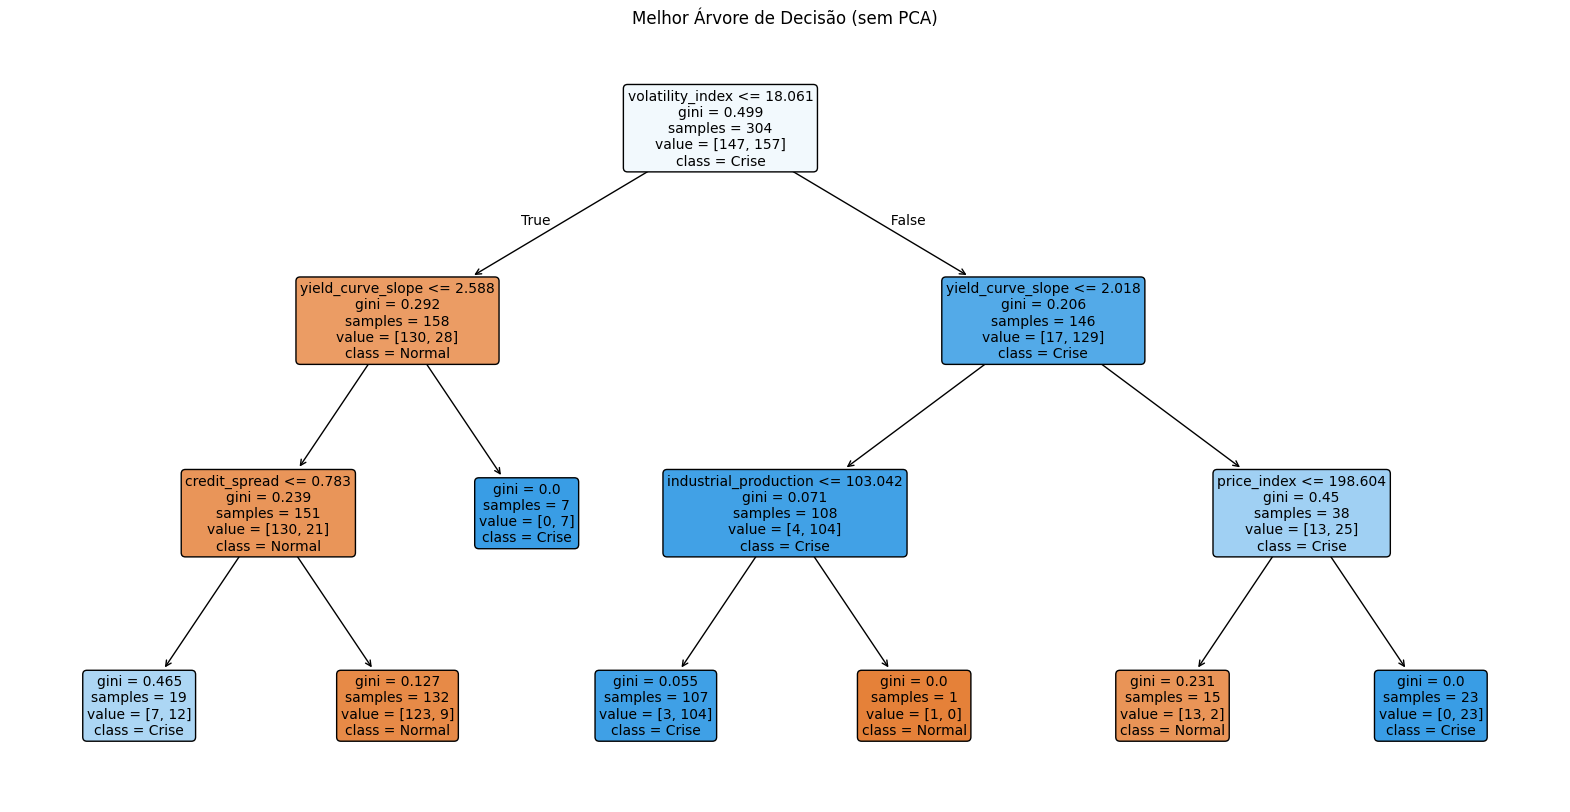


===== Decision Tree (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.77      0.67      0.72       147
       Crise       0.73      0.81      0.77       157

    accuracy                           0.74       304
   macro avg       0.75      0.74      0.74       304
weighted avg       0.75      0.74      0.74       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.71      0.56      0.63        91
       Crise       0.32      0.47      0.38        40

    accuracy                           0.53       131
   macro avg       0.52      0.52      0.50       131
weighted avg       0.59      0.53      0.55       131


Tempo de treino: 0.0150 s
Tempo de predição: 2.0189 ms
Memória utilizada: 214.12 MB


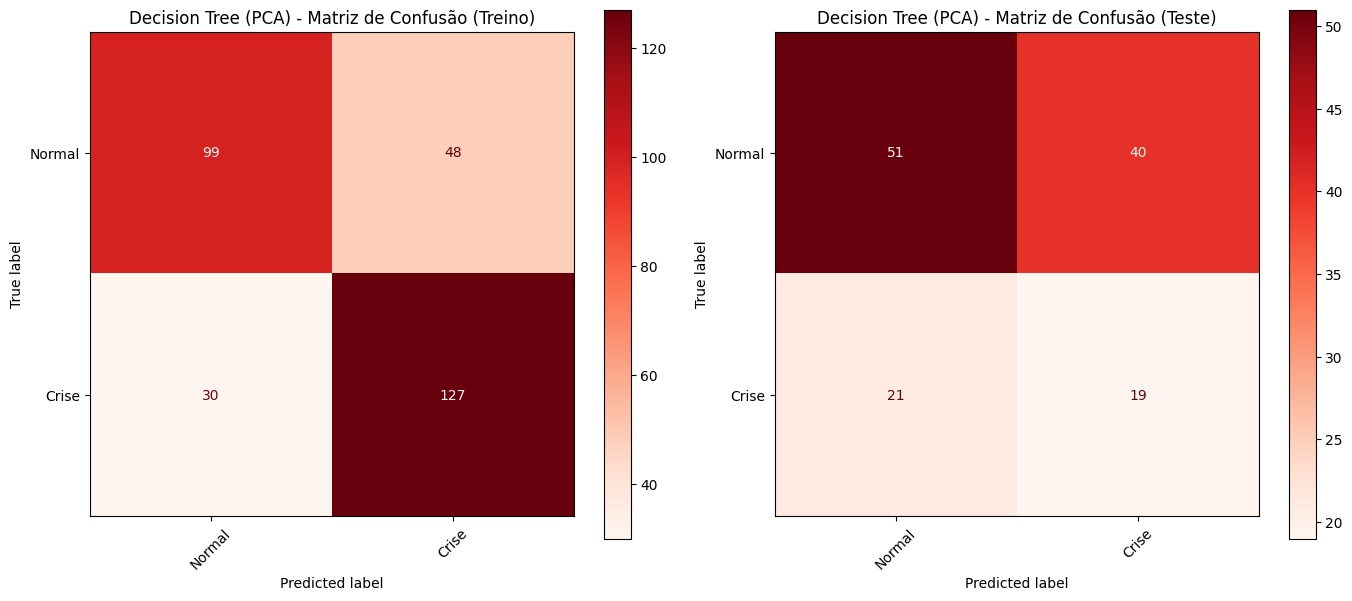

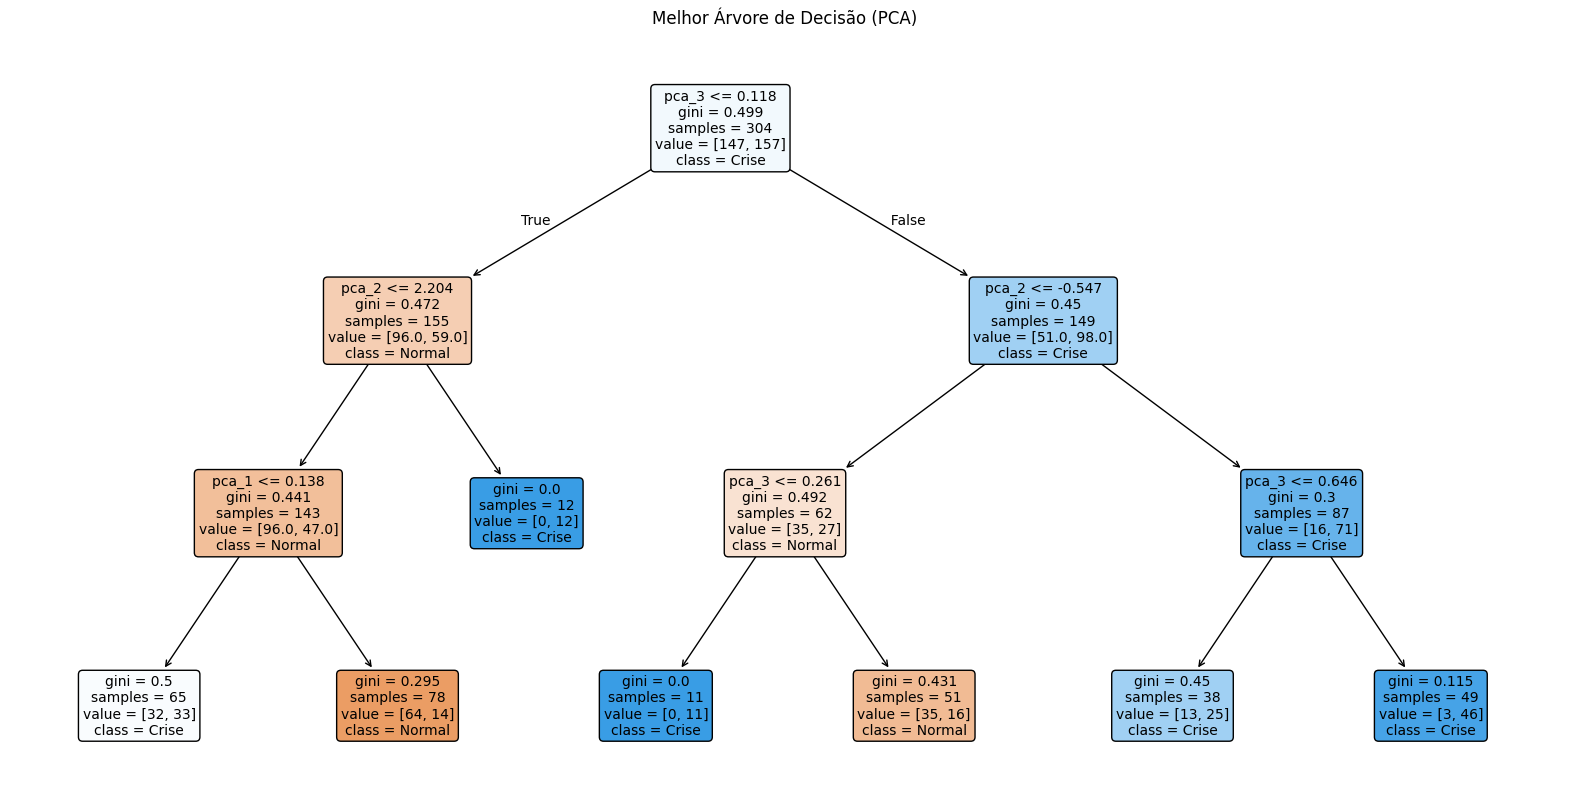

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# ===== TREINAR SEM PCA =====
best_tree_no_pca = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.0,
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=2
)

inicio_treino = time.time()

best_tree_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_tree_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    best_tree_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Decision Tree (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_no_pca,
    feature_names=features,
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (sem PCA)")
plt.show()

# ===== TREINAR COM PCA =====
best_tree_pca = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.0,
    max_depth=3,
    min_samples_leaf=2,
    min_samples_split=2
)

inicio_treino = time.time()

best_tree_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_tree_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    best_tree_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Decision Tree (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_pca,
    feature_names=["pca_1", "pca_2", "pca_3"],
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (PCA)")
plt.show()

KNN


===== KNN (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.89      0.95      0.91       147
       Crise       0.95      0.89      0.91       157

    accuracy                           0.91       304
   macro avg       0.92      0.92      0.91       304
weighted avg       0.92      0.91      0.91       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.70      0.67      0.69        91
       Crise       0.32      0.35      0.33        40

    accuracy                           0.57       131
   macro avg       0.51      0.51      0.51       131
weighted avg       0.58      0.57      0.58       131


Tempo de treino: 0.0020 s
Tempo de predição: 49.0806 ms
Memória utilizada: 212.94 MB


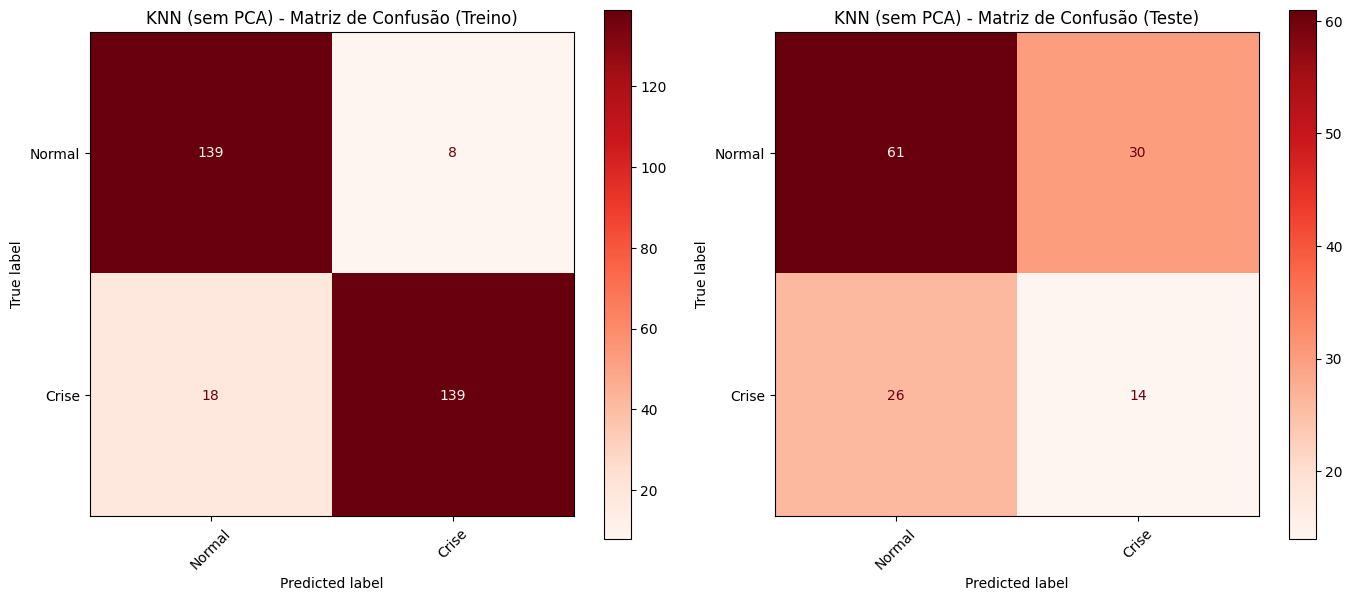


===== KNN (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       147
       Crise       1.00      1.00      1.00       157

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.89      0.46      0.61        91
       Crise       0.42      0.88      0.56        40

    accuracy                           0.59       131
   macro avg       0.66      0.67      0.59       131
weighted avg       0.75      0.59      0.60       131


Tempo de treino: 0.0193 s
Tempo de predição: 0.0000 ms
Memória utilizada: 212.21 MB


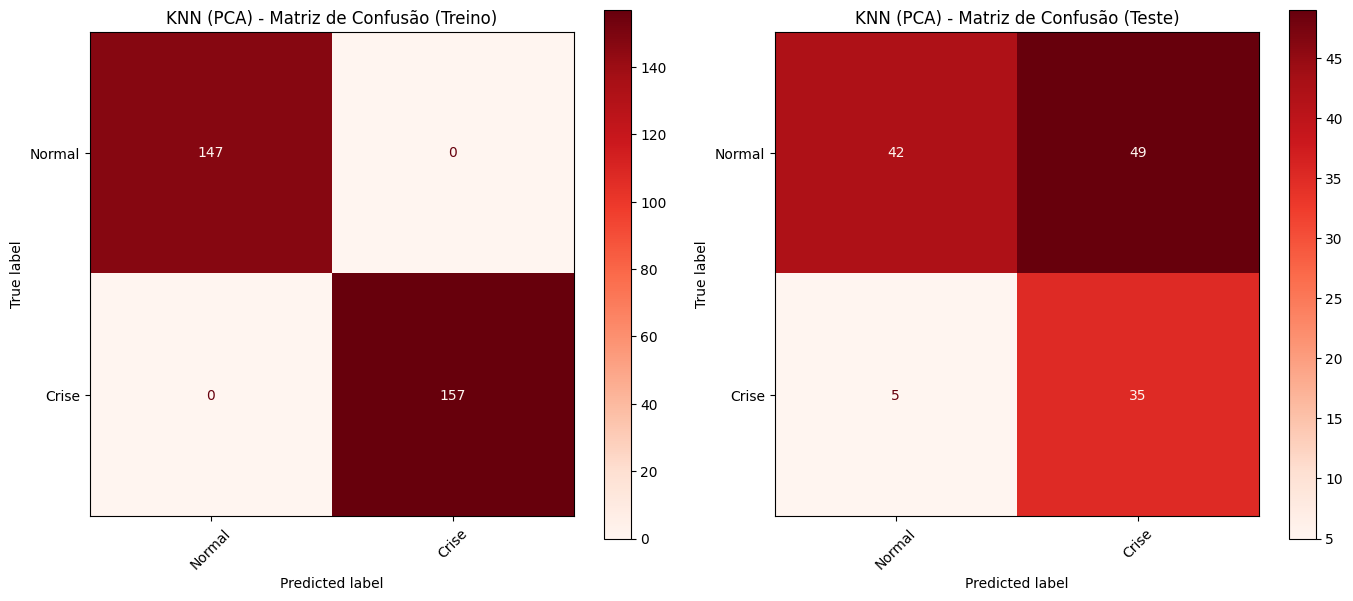

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ===== TREINAR SEM PCA =====
best_knn_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        metric="manhattan",
        n_neighbors=11,
        weights="uniform"
    ))
])

inicio_treino = time.time()

best_knn_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_knn_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    best_knn_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="KNN (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

# ===== TREINAR COM PCA =====
best_knn_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        metric="manhattan",
        n_neighbors=3,
        weights="distance"
    ))
])

inicio_treino = time.time()

best_knn_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_knn_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    best_knn_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="KNN (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

Voting Classifier


===== Voting Ensemble (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98       147
       Crise       0.98      0.97      0.98       157

    accuracy                           0.98       304
   macro avg       0.98      0.98      0.98       304
weighted avg       0.98      0.98      0.98       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.77      0.44      0.56        91
       Crise       0.35      0.70      0.47        40

    accuracy                           0.52       131
   macro avg       0.56      0.57      0.52       131
weighted avg       0.64      0.52      0.53       131


Tempo de treino: 0.7508 s
Tempo de predição: 45.0022 ms
Memória utilizada: 217.57 MB


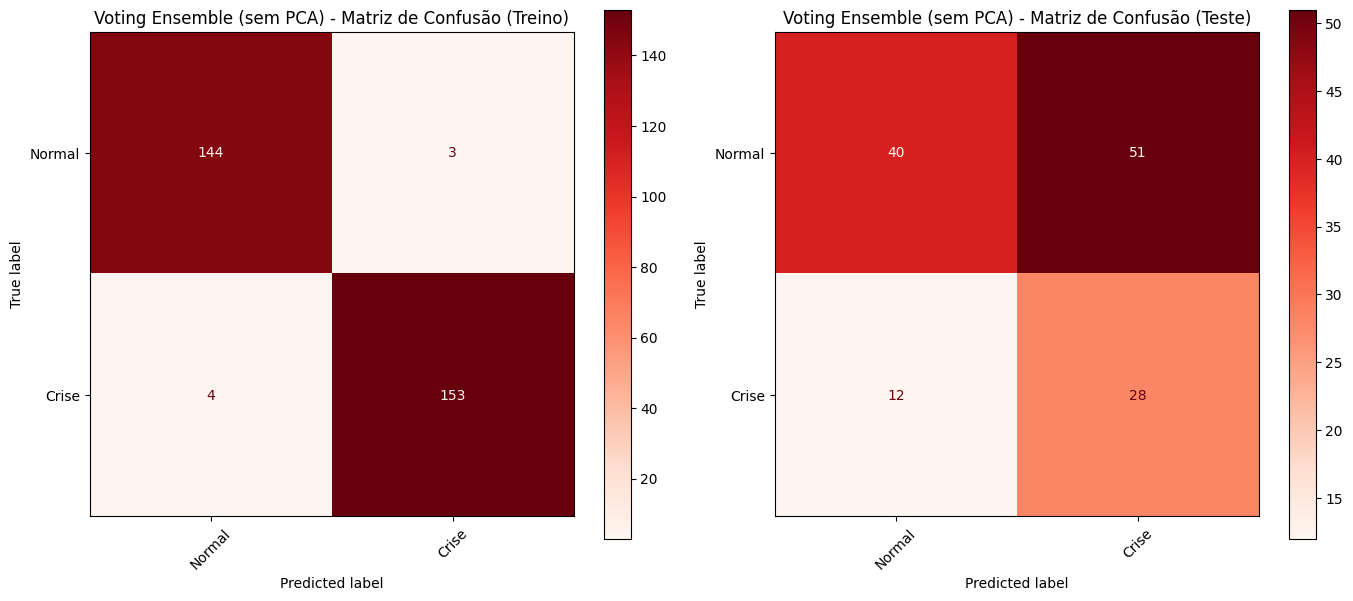


===== Voting Ensemble (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.93      0.96      0.95       147
       Crise       0.96      0.94      0.95       157

    accuracy                           0.95       304
   macro avg       0.95      0.95      0.95       304
weighted avg       0.95      0.95      0.95       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.76      0.57      0.65        91
       Crise       0.38      0.60      0.47        40

    accuracy                           0.58       131
   macro avg       0.57      0.59      0.56       131
weighted avg       0.65      0.58      0.60       131


Tempo de treino: 0.6231 s
Tempo de predição: 38.0037 ms
Memória utilizada: 224.50 MB


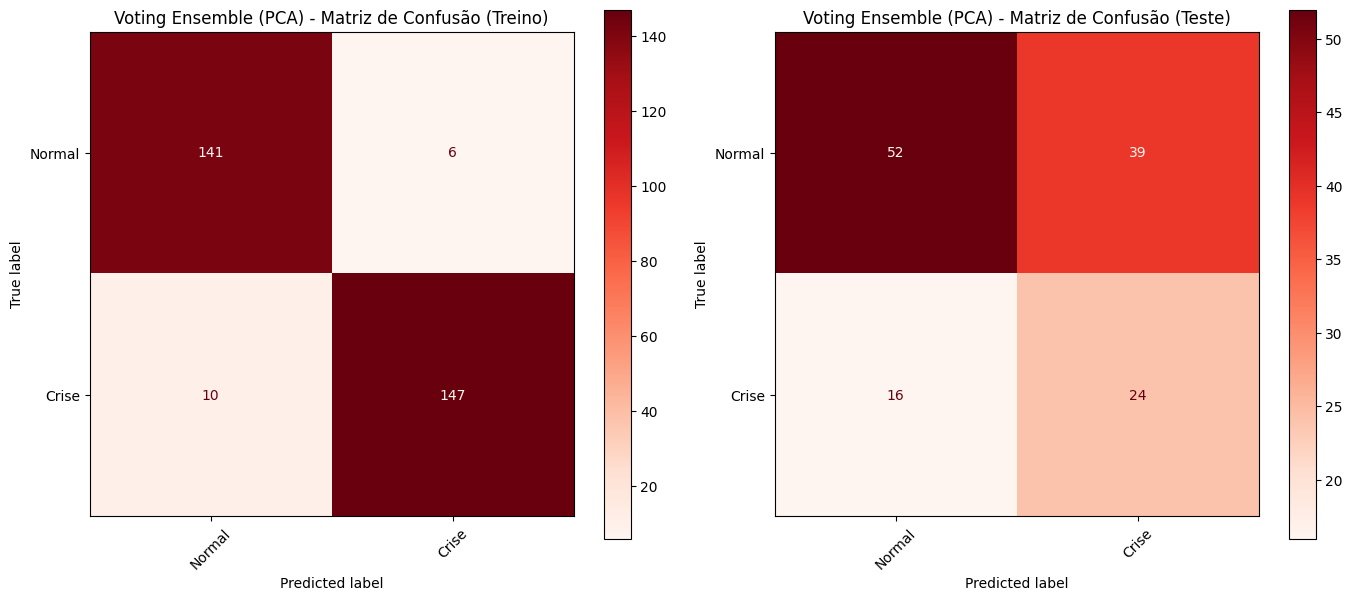

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== MODELOS BASE =====
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

# =====================================================
# VOTING SEM PCA
# =====================================================

voting_no_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)

inicio_treino = time.time()

voting_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

voting_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    voting_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Voting Ensemble (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

# =====================================================
# VOTING COM PCA
# =====================================================

voting_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)

inicio_treino = time.time()

voting_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

voting_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    voting_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Voting Ensemble (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

Random Forest


===== Random Forest (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       147
       Crise       1.00      1.00      1.00       157

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.77      0.63      0.69        91
       Crise       0.40      0.57      0.47        40

    accuracy                           0.61       131
   macro avg       0.59      0.60      0.58       131
weighted avg       0.66      0.61      0.62       131


Tempo de treino: 0.7635 s
Tempo de predição: 40.5424 ms
Memória utilizada: 233.75 MB


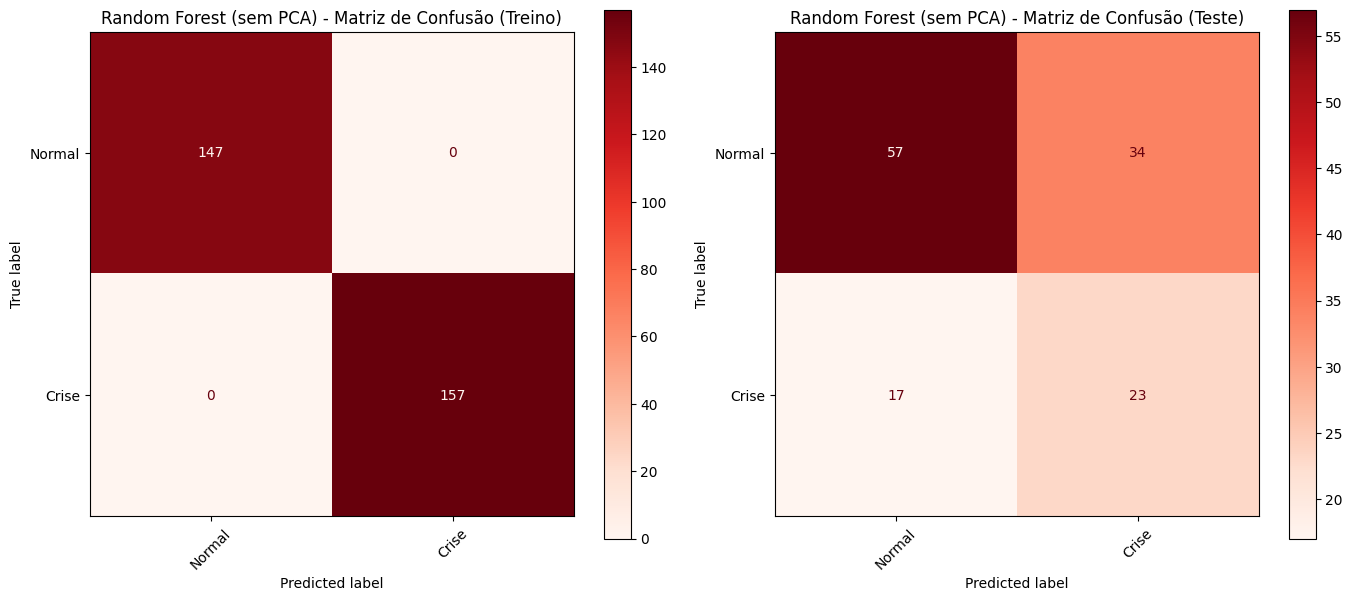


Importância das variáveis (sem PCA):
                      feature  importance
10           volatility_index    0.292482
5                 price_index    0.160246
12          yield_curve_slope    0.092572
2       industrial_production    0.091077
4   industrial_production_yoy    0.074390
8               real_interest    0.065891
0               credit_spread    0.059287
7               inflation_yoy    0.041394
1          credit_spread_diff    0.028338
13     yield_curve_slope_diff    0.023887
9          real_interest_diff    0.018828
6               inflation_mom    0.018435
11       volatility_index_mom    0.017818
3   industrial_production_mom    0.015353


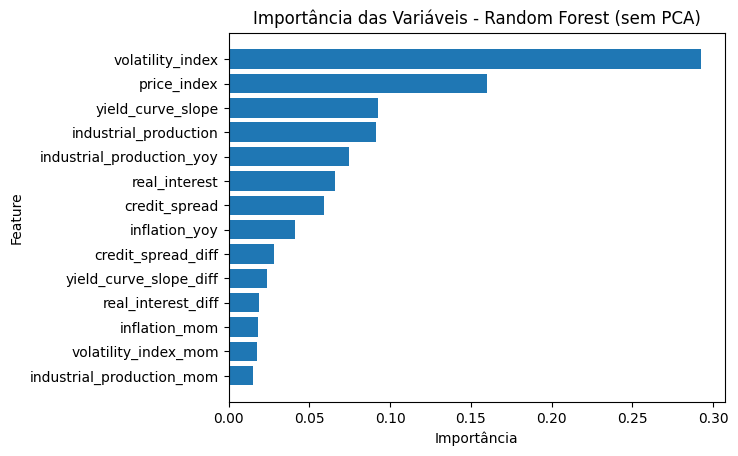


===== Random Forest (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.85      0.83      0.84       147
       Crise       0.84      0.87      0.86       157

    accuracy                           0.85       304
   macro avg       0.85      0.85      0.85       304
weighted avg       0.85      0.85      0.85       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.83      0.53      0.64        91
       Crise       0.41      0.75      0.53        40

    accuracy                           0.60       131
   macro avg       0.62      0.64      0.59       131
weighted avg       0.70      0.60      0.61       131


Tempo de treino: 0.2489 s
Tempo de predição: 11.0071 ms
Memória utilizada: 218.81 MB


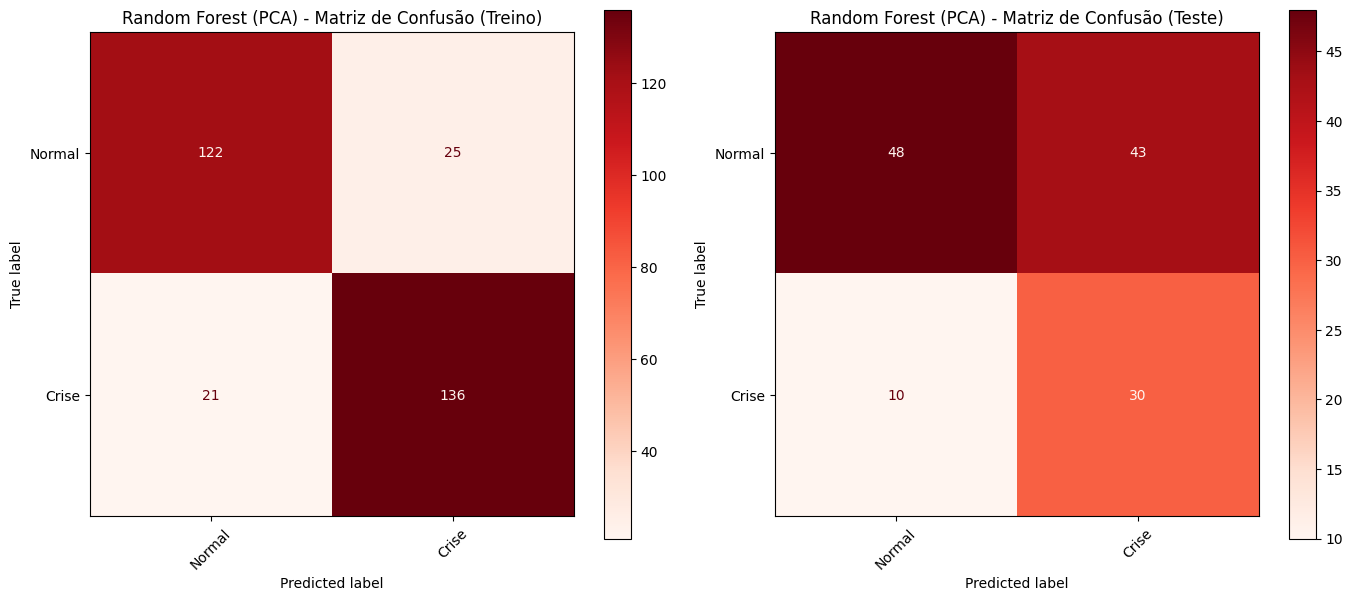


Importância das componentes PCA:
  feature  importance
2   pca_3    0.338696
1   pca_2    0.336041
0   pca_1    0.325263


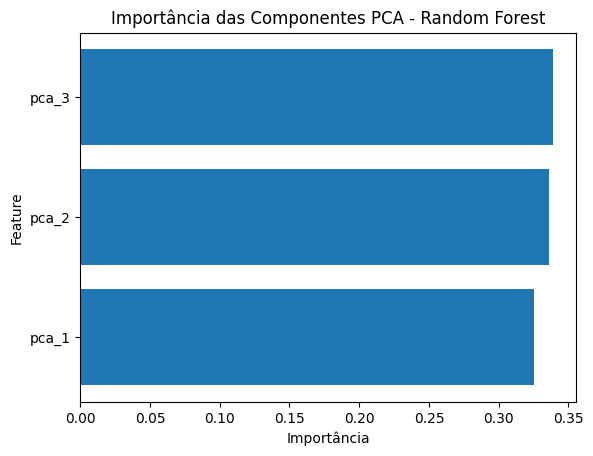

In [8]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil
import os

# ===== TREINAR SEM PCA =====
best_rf_no_pca = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100
)

inicio_treino = time.time()

best_rf_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_rf_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    best_rf_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Random Forest (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

importances = best_rf_no_pca.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nImportância das variáveis (sem PCA):")
print(df_importance)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest (sem PCA)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

# ===== TREINAR COM PCA =====
best_rf_pca = RandomForestClassifier(
    random_state=42,
    class_weight=None,
    max_depth=5,
    min_samples_leaf=2,
    min_samples_split=10,
    n_estimators=100
)

inicio_treino = time.time()

best_rf_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_rf_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    best_rf_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Random Forest (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

importances_pca = best_rf_pca.feature_importances_

df_importance_pca = pd.DataFrame({
    "feature": ["pca_1", "pca_2", "pca_3"],
    "importance": importances_pca
}).sort_values(by="importance", ascending=False)

print("\nImportância das componentes PCA:")
print(df_importance_pca)

plt.figure()
plt.barh(df_importance_pca["feature"], df_importance_pca["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Componentes PCA - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

Comparação Final

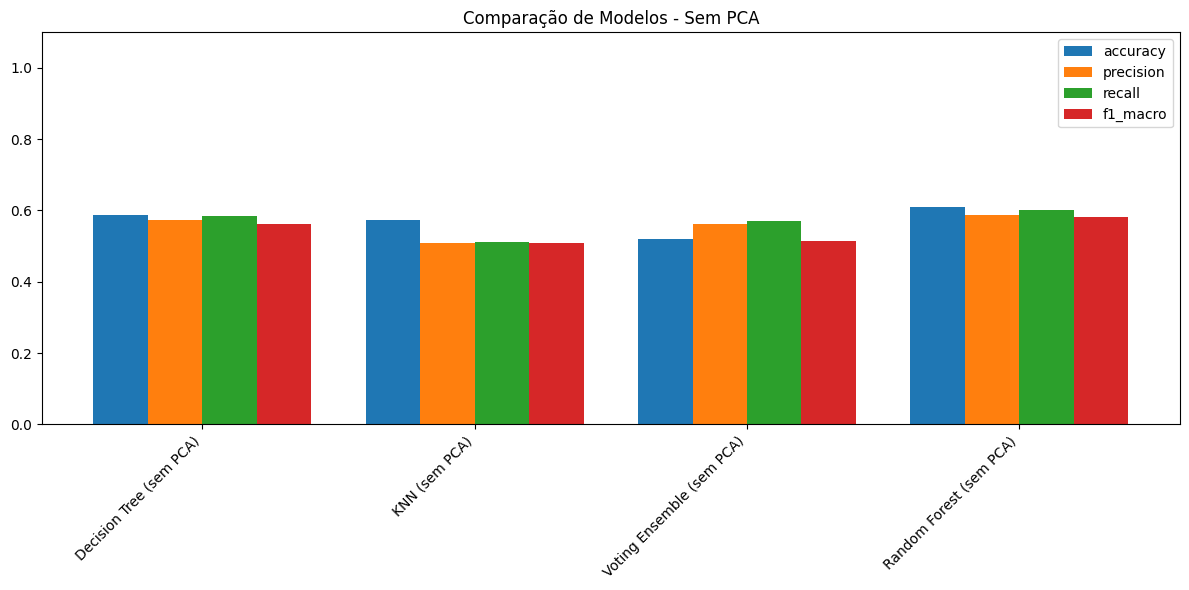

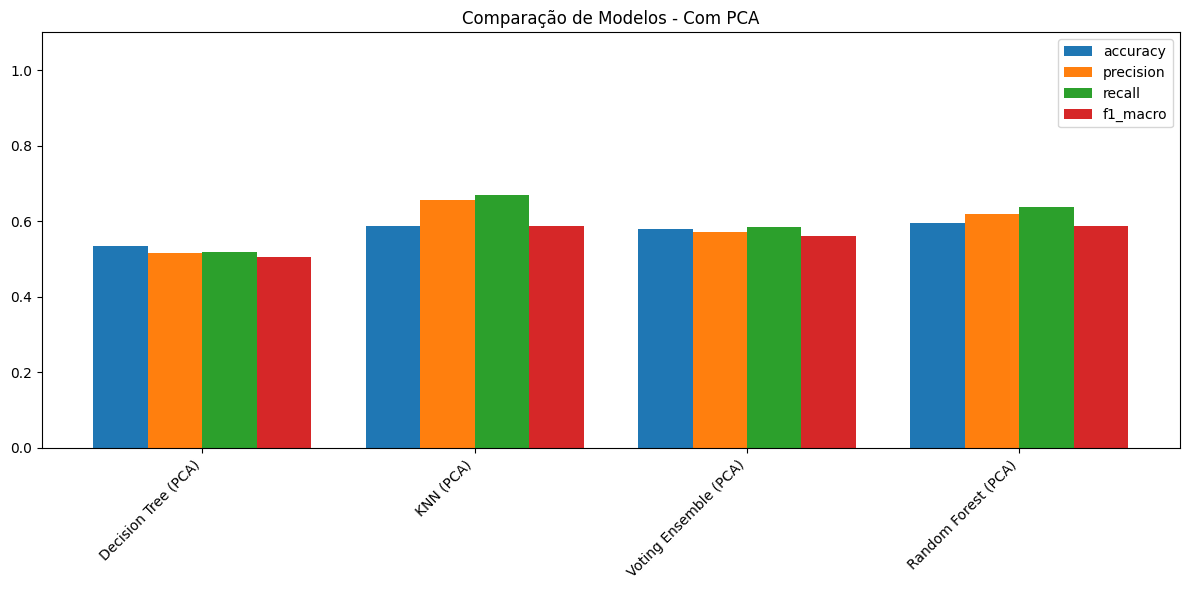

In [9]:
import numpy as np
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(resultados).set_index("modelo")

metricas = ["accuracy", "precision", "recall", "f1_macro"]
width = 0.2

# SEM PCA
modelos_sem_pca = [m for m in df_resultados.index if "sem PCA" in m]
df_sem_pca = df_resultados.loc[modelos_sem_pca]
x = np.arange(len(df_sem_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_sem_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_sem_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Sem PCA")
ax.legend()
plt.tight_layout()
plt.show()

# COM PCA
modelos_com_pca = [m for m in df_resultados.index if "sem PCA" not in m]
df_com_pca = df_resultados.loc[modelos_com_pca]
x = np.arange(len(df_com_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_com_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_com_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Com PCA")
ax.legend()
plt.tight_layout()
plt.show()

Tabela Comparativa: Sem PCA x Com PCA

In [10]:
import pandas as pd
import numpy as np

df_resultados = pd.DataFrame(resultados)

# Separa o nome base do modelo (tira o sufixo "(sem PCA)" / "(PCA)")
df_resultados["modelo_base"] = df_resultados["modelo"].str.replace(
    r"\s*\((sem PCA|PCA)\)", "", regex=True
)
df_resultados["versao"] = df_resultados["modelo"].apply(
    lambda x: "sem_pca" if "sem PCA" in x else "pca"
)

metricas = ["accuracy", "precision", "recall", "f1_macro", "tempo_treino_s"]

# Pivota: uma linha por modelo, colunas separadas por versão
tabela = df_resultados.pivot(
    index="modelo_base",
    columns="versao",
    values=metricas
)

linhas = []

for modelo_base in tabela.index:
    linha = {"Modelo": modelo_base}

    for metrica in metricas:
        sem_pca = tabela.loc[modelo_base, (metrica, "sem_pca")]
        com_pca = tabela.loc[modelo_base, (metrica, "pca")]

        # Variação percentual (tratando tempo separadamente,
        # já que "melhora" no tempo é diminuir, não aumentar)
        if pd.notna(sem_pca) and sem_pca != 0:
            variacao = ((com_pca - sem_pca) / sem_pca) * 100
        else:
            variacao = np.nan

        nome_col = metrica.replace("_macro", "").replace("_s", "").capitalize()

        linha[f"{nome_col} (sem PCA)"] = round(sem_pca, 4)
        linha[f"{nome_col} (com PCA)"] = round(com_pca, 4)
        linha[f"{nome_col} (Δ %)"] = round(variacao, 4)

    linhas.append(linha)

df_comparativo = pd.DataFrame(linhas).set_index("Modelo")

colunas_delta = [c for c in df_comparativo.columns if "Δ" in c]
colunas_delta_tempo = [c for c in colunas_delta if "Tempo" in c]
colunas_delta_metricas = [c for c in colunas_delta if c not in colunas_delta_tempo]
colunas_valores = [c for c in df_comparativo.columns if c not in colunas_delta]

def cor_variacao(coluna, inverter=False):
    def aplicar(val):
        if isinstance(val, (int, float)) and not pd.isna(val):
            positivo = val < 0 if inverter else val > 0
            negativo = val > 0 if inverter else val < 0
            if positivo:
                return "color: green; font-weight: bold"
            elif negativo:
                return "color: red; font-weight: bold"
        return ""
    return coluna.map(aplicar)

print("\n===== TABELA COMPARATIVA: SEM PCA x COM PCA =====")
display(
    df_comparativo.style
    .format("{:.4f}", subset=colunas_valores)
    .format("{:+.4f}%", subset=colunas_delta)
    .apply(cor_variacao, subset=colunas_delta_metricas)
    .apply(cor_variacao, inverter=True, subset=colunas_delta_tempo)
)


===== TABELA COMPARATIVA: SEM PCA x COM PCA =====


,Accuracy (sem PCA),Accuracy (com PCA),Accuracy (Δ %),Precision (sem PCA),Precision (com PCA),Precision (Δ %),Recall (sem PCA),Recall (com PCA),Recall (Δ %),F1 (sem PCA),F1 (com PCA),F1 (Δ %),Tempo_treino (sem PCA),Tempo_treino (com PCA),Tempo_treino (Δ %)
Modelo,,,,,,,,,,,,,,,
Decision Tree,0.5878,0.5344,-9.0909%,0.5719,0.5152,-9.9248%,0.5842,0.5177,-11.3802%,0.5633,0.5048,-10.3901%,0.0157,0.0150,-5.0334%
KNN,0.5725,0.5878,+2.6667%,0.5097,0.6551,+28.5435%,0.5102,0.6683,+30.9908%,0.5094,0.5866,+15.1645%,0.0020,0.0193,+861.3908%
Random Forest,0.6107,0.5954,-2.5000%,0.5869,0.6193,+5.5177%,0.6007,0.6387,+6.3343%,0.5826,0.5876,+0.8697%,0.7635,0.2489,-67.4033%
Voting Ensemble,0.5191,0.5802,+11.7647%,0.5618,0.5728,+1.9576%,0.5698,0.5857,+2.7965%,0.5150,0.5601,+8.7453%,0.7508,0.6231,-17.0156%
